In [1]:
import os, sys
parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

Datasets:   0%|          | 0/7 [00:00<?, ?it/s]

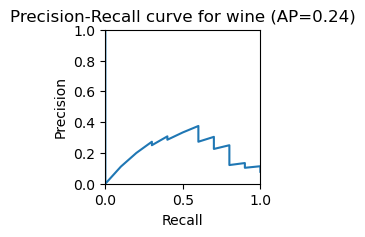

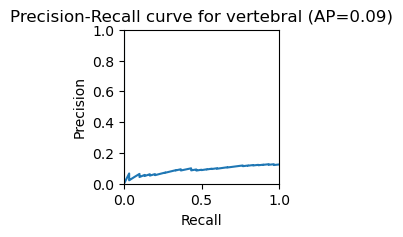

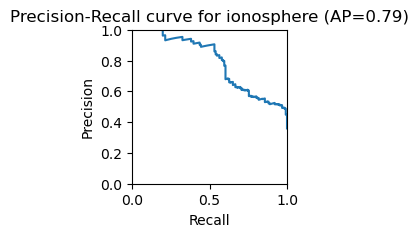

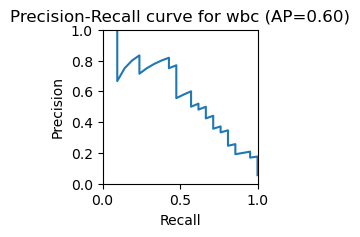

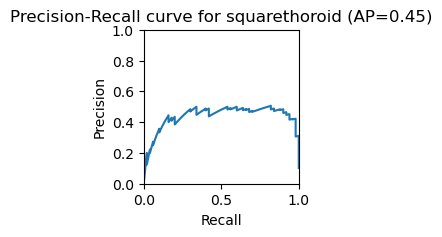

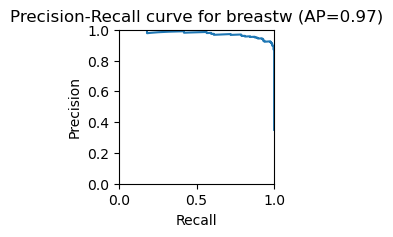

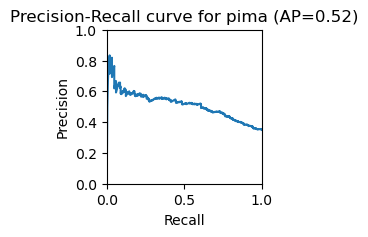

In [2]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import experiments.datasets as datasets
from models.isolationforest import IsolationForest

from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve

for dataset_name in tqdm(datasets.small_datasets_names, desc="Datasets"):
    data, labels = datasets.load(dataset_name)
    iforest = IsolationForest(parallel_jobs=16, n_trees=128)
    scores = iforest.fit_predict(data)
    
    precision, recall, _ = precision_recall_curve(labels, scores)
    average_precision = average_precision_score(labels, scores)
    
    plt.figure(figsize=(2, 2))
    plt.plot(recall, precision)
    plt.title(f"Precision-Recall curve for {dataset_name} (AP={average_precision:.2f})")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()